# TODO: Project title (e.g. "Predicting X with Tree-Based Models")
## Decision tree, random forest, AdaBoost, and XGBoost on the TODO dataset

**Authors:** TODO name (`netid`) and TODO name (`netid`)  
**Course:** CS 4372  
**Dataset:** [TODO dataset name](TODO-url)

This notebook is the complete, reproducible analysis behind the accompanying report. TODO: replace this
paragraph with one that names the data source, the prediction task, how data quality is audited, how the
four tree models are tuned, and how they are evaluated on one untouched test set.

### How to use this scaffold

- Work **top to bottom**. Each section opens with what to do and which assignment requirement it satisfies.
- Blocks that start with `> **Hint**` are prompts, not answers. Delete them as you finish a section.
- Code cells that contain `# TODO` are yours to write. Cells without one (imports, settings, `save_fig`) are boilerplate.
- Every figure goes through `save_fig("NN_name")`. The file names are the ones `Trees_Models_Report.tex` expects, so a
  figure appears in the report automatically once it exists in `figs/`.
- Export each experiment log to `results/` so tuning evidence is auditable.
- Prose written here (interpretations, conclusions) is the raw material for the report. The report itself must contain
  **no code**.

### Analysis info

Fill these in before writing any code, then keep them consistent with the report.

- **Task:** TODO classification or regression. (ROC curves, precision-recall curves, and confusion matrices are only
  defined for classification, so a regression task needs different result-analysis plots. See the README.)
- **Target:** TODO column name, its classes or units, and class balance if classification.
- **Predictors:** TODO list, and which are categorical.
- **Primary model-selection metric:** TODO e.g. five-fold cross-validated F1 or ROC AUC on the training data. Justify it.
- **Final evaluation:** TODO train/test split proportions and `random_state`. The test set must not be used for
  preprocessing, feature selection, or tuning.
- **Statistical scope:** TODO what the models can and cannot claim (associations, not causes).

In [68]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn
import sklearn.model_selection
import sklearn.preprocessing
from sklearn.model_selection import train_test_split
import sklearn.pipeline
import sklearn.metrics
import sklearn.tree
import sklearn.ensemble
import sklearn.inspection
import sklearn.exceptions
import sklearn as skl
import xgboost as xgb

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", skl.__version__)
print("xgboost:", xgb.__version__)

numpy: 2.2.5
pandas: 2.3.2
scikit-learn: 1.7.2
xgboost: 3.4.1


In [ ]:
# Reproducible display and plotting settings
RANDOM_STATE = 4372

DATA_URL = "https://raw.githubusercontent.com/DavidMwaria/Trees_Models_HW2/refs/heads/main/mushroom/agaricus-lepiota.data"
COLUMNS = ["poisonous", "cap-shape", "cap-surface", "cap-color", "bruises", "odor", "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape", "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring", "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color", "ring-number", "ring-type", "spore-print-color", "population", "habitat"]
TARGET = "poisonous"
TASK = "classification"

PALETTE = {"primary": "#A51C30", "secondary": "#4C72B0", "muted": "#C9A0A8"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# These folders make a fresh Colab/Jupyter run self-contained.
os.makedirs("figs", exist_ok=True)
os.makedirs("results", exist_ok=True)


def save_fig(name):
    """Save the current Matplotlib figure as figs/<name>.pdf (the report picks it up by name)."""
    plt.savefig(f"figs/{name}.pdf", bbox_inches="tight")

## 1. Load the public data

**Requirement:** load the data into a pandas DataFrame from a public URL.

> **Hint:** Does the raw file have a header row? Reading a headerless file with pandas' defaults silently turns the
> first observation into column names. Assert the expected shape so a wrong URL or wrong header setting fails loudly.

In [32]:
raw = pd.read_csv(DATA_URL, header=None, names=COLUMNS)
assert raw.shape == (8124, 23), f"Expected shape (8124, 23), but got {raw.shape}"
print(f"Dimensions: {raw.shape}")
print(raw.head())

Dimensions: (8124, 23)
  poisonous cap-shape cap-surface cap-color bruises odor gill-attachment  \
0         p         x           s         n       t    p               f   
1         e         x           s         y       t    a               f   
2         e         b           s         w       t    l               f   
3         p         x           y         w       t    p               f   
4         e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color stalk-shape stalk-root  \
0            c         n          k           e          e   
1            c         b          k           e          c   
2            c         b          n           e          c   
3            c         n          n           e          e   
4            w         b          k           t          e   

  stalk-surface-above-ring stalk-surface-below-ring stalk-color-above-ring  \
0                        s                        s                  

In [33]:
# TODO: build a variable dictionary DataFrame with columns
#       Variable | Role (Predictor/Target) | Type | Meaning | Unit
LEVELS = {
    "poisonous": {"p": "poisonous", "e": "edible"},
    "cap-shape": {"b": "bell", "c": "conical", "x": "convex",
                  "f": "flat", "k": "knobbed", "s": "sunken"},
    "cap-surface": {"f": "fibrous", "g": "grooves", "y": "scaly", "s": "smooth"},
    "cap-color": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "r": "green",
              "p": "pink", "u": "purple", "e": "red", "w": "white", "y": "yellow"},
    "bruises": {"t": "bruises", "f": "no"},
    "odor": {"a": "almond", "l": "anise", "c": "creosote", "y": "fishy", "f": "foul", "m": "musty", "n": "none", "p": "pungent", "s": "spicy"},
    "gill-attachment": {"a": "attached", "d": "descending", "f": "free", "n": "notched"},
    "gill-spacing": {"c": "close", "w": "crowded", "d": "distant"},
    "gill-size": {"b": "broad", "n": "narrow"},
    "gill-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "g": "gray", "r": "green", "o": "orange", "p": "pink", "u": "purple", "e": "red", "w": "white", "y": "yellow"},
    "stalk-shape": {"e": "enlarging", "t": "tapering"},
    "stalk-root": {"b": "bulbous", "c": "club", "u": "cup", "e": "equal", "z": "rhizomorphs", "r": "rooted", "?": "missing"},
    "stalk-surface-above-ring": {"f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth"},
    "stalk-surface-below-ring": {"f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth"},
    "stalk-color-above-ring": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "o": "orange", "p": "pink", "e": "red", "w": "white", "y": "yellow"},
    "stalk-color-below-ring": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "o": "orange", "p": "pink", "e": "red", "w": "white", "y": "yellow"},
    "veil-type": {"p": "partial", "u": "universal"},
    "veil-color": {"n": "brown", "o": "orange", "w": "white", "y": "yellow"},
    "ring-number": {"n": "none", "o": "one", "t": "two"},
    "ring-type": {"c": "cobwebby", "e": "evanescent", "f": "flaring", "l": "large", "n": "none", "p": "pendant", "s": "sheathing", "z": "zone"},
    "spore-print-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "r": "green", "o": "orange", "u": "purple", "w": "white", "y": "yellow"},
    "population": {"a": "abundant", "c": "clustered", "n": "numerous", "s": "scattered", "v": "several", "y": "solitary"},
    "habitat": {"g": "grasses", "l": "leaves", "m": "meadows", "p": "paths", "u": "urban", "w": "waste", "d": "woods"}
}

variable_dict = pd.DataFrame({
    "Variable": COLUMNS,
    "Role": ["Target"] + ["Predictor"] * (len(COLUMNS) - 1),
    "Type": ["Categorical"] * len(COLUMNS),
    "Meaning": [
        "Whether the mushroom is poisonous or edible",
        "Shape of the mushroom cap",
        "Surface texture of the mushroom cap",
        "Color of the mushroom cap",
        "Presence of bruises on the mushroom",
        "Odor of the mushroom",
        "Attachment of the gills to the stalk",
        "Spacing of the gills",
        "Size of the gills",
        "Color of the gills",
        "Shape of the stalk",
        "Root type of the stalk",
        "Surface texture of the stalk above the ring",
        "Surface texture of the stalk below the ring",
        "Color of the stalk above the ring",
        "Color of the stalk below the ring",
        "Type of veil present on the mushroom",
        "Color of the veil",
        "Number of rings on the stalk",
        "Type of ring on the stalk",
        "Color of the spore print",
        "Population density of the mushroom",
        "Habitat where the mushroom is found",
    ]
})

TODO: one paragraph on anything the source documentation says that affects analysis (scaling already applied,
coded missing values, how the target was defined).

## 2. Audit missingness, duplicates, types, and consistency

**Requirement:** examine the data for consistency; check null values, missing data, and inconsistencies, and handle
them before proceeding.

> **Hint:** Missing-value counts alone are not enough. Look for impossible values, placeholder codes (such as 0 or -1
> standing in for "missing"), invalid category labels, and duplicates. Write each rule down *before* looking at the
> target so no model is favored, and keep ordinary outliers unless they are clearly invalid.

In [34]:
for column, mapping in LEVELS.items():
    unexpected = set(raw[column].unique()) - set(mapping)
    assert not unexpected, f"{column}: codes in data but not in LEVELS: {unexpected}"

In [35]:
# TODO: audit table with dtype, missing count, and unique count per column;
#       also report exact duplicate rows and the set of categories in each categorical column.
unique_audit = raw.nunique().to_frame(name="unique")
missing_audit = (raw.isna().sum() + raw.eq("?").sum()).to_frame(name="missing")
exact_duplicates = raw.duplicated().sum()
print("\nExact Duplicate Rows Audit:\n", exact_duplicates)
print("\nMissing Values Audit:\n", missing_audit)
print("\nUnique Values Audit:\n", unique_audit)
print(raw.info())


Exact Duplicate Rows Audit:
 0

Missing Values Audit:
                           missing
poisonous                       0
cap-shape                       0
cap-surface                     0
cap-color                       0
bruises                         0
odor                            0
gill-attachment                 0
gill-spacing                    0
gill-size                       0
gill-color                      0
stalk-shape                     0
stalk-root                   2480
stalk-surface-above-ring        0
stalk-surface-below-ring        0
stalk-color-above-ring          0
stalk-color-below-ring          0
veil-type                       0
veil-color                      0
ring-number                     0
ring-type                       0
spore-print-color               0
population                      0
habitat                         0

Unique Values Audit:
                           unique
poisonous                      2
cap-shape                      6
cap-su

Notice that veil-type has no variation between rows, giving us no additional information to aid classification. We can safely drop this feature.

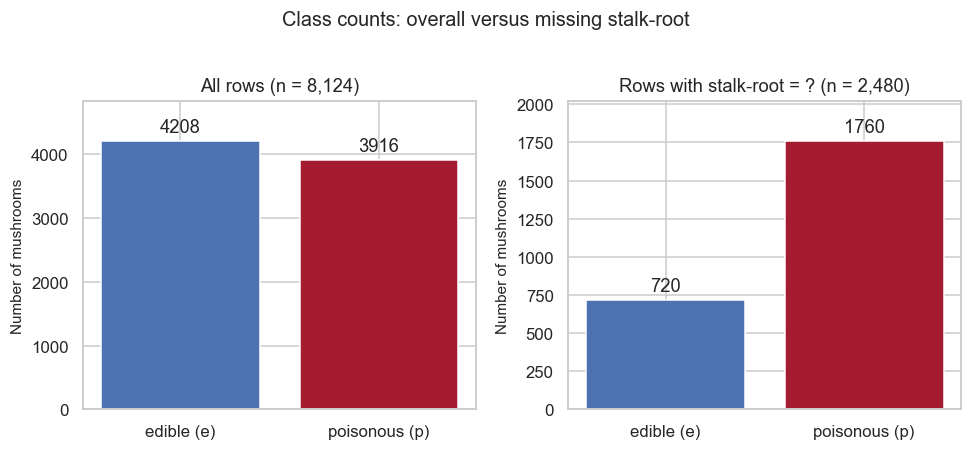

In [44]:
missing_rows = raw[raw["stalk-root"] == "?"]

order = ["e", "p"]
labels = ["edible (e)", "poisonous (p)"]
colors = [PALETTE["secondary"], PALETTE["primary"]]

overall_counts = raw[TARGET].value_counts().reindex(order, fill_value=0)
missing_counts = missing_rows[TARGET].value_counts().reindex(order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for axis, counts, title in [
    (axes[0], overall_counts, f"All rows (n = {overall_counts.sum():,})"),
    (axes[1], missing_counts, f"Rows with stalk-root = ? (n = {missing_counts.sum():,})"),
]:
    bars = axis.bar(labels, counts.values, color=colors)
    axis.bar_label(bars, padding=3)
    axis.set_title(title)
    axis.set_ylabel("Number of mushrooms")
    axis.set_ylim(0, counts.max() * 1.15)

plt.suptitle("Class counts: overall versus missing stalk-root", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Additionally, `stalk-root` has missing values encoded as "?". We do not know whether these values are missing because of a property of the mushrooms or because of how the data were collected. About 30% of rows have `stalk-root` missing, and of these rows, 70% are poisonous compared with 48% of the overall dataset. If the missingness is a data-collection artifact, a model that relies on it would learn a pattern that may not carry over to new observations. We therefore exclude `stalk-root` from training.

In [47]:
pd.crosstab(raw["ring-number"], raw["ring-type"])

ring-type,e,f,l,n,p
ring-number,,,,,
n,0,0,0,36,0
o,2584,48,1296,0,3560
t,192,0,0,0,408


Above, we confirm that any any mushroom marked **none** for `ring-type` is also marked **none** for `ring-number`. Aside from this, all the features in this dataset are categorical, so, having checked that the values in each column match the values defined in the variable dictionary, we can be sure there are no impossible values or outliers. 

In [54]:
cleaned = raw.drop(columns=["veil-type", "stalk-root"])
removed = raw[["veil-type", "stalk-root"]]
print(f"Rows removed: 0")
print(f"Columns removed: {raw.shape[1] - cleaned.shape[1]}")
print(f"Rows retained: {cleaned.shape[0]}")
print(raw.shape, "->", cleaned.shape)

Rows removed: 0
Columns removed: 2
Rows retained: 8124
(8124, 23) -> (8124, 21)


In summary, the clean dataset simply drops the features `veil-type` and `stalk-root`.

## 3. Describe distribution shape

**Requirement:** obtain a summary of the attributes. Are they normally distributed? If not, what could be the reason?

> **Hint:** Skewness and kurtosis describe shape; a formal test (Anderson-Darling, Shapiro-Wilk, ...) checks
> normality. For classification, also show the class balance. Then discuss *why* distributions look the way they do,
> and whether normality matters for the four tree models at all.

In [55]:
cleaned.describe().T

,count,unique,top,freq
poisonous,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


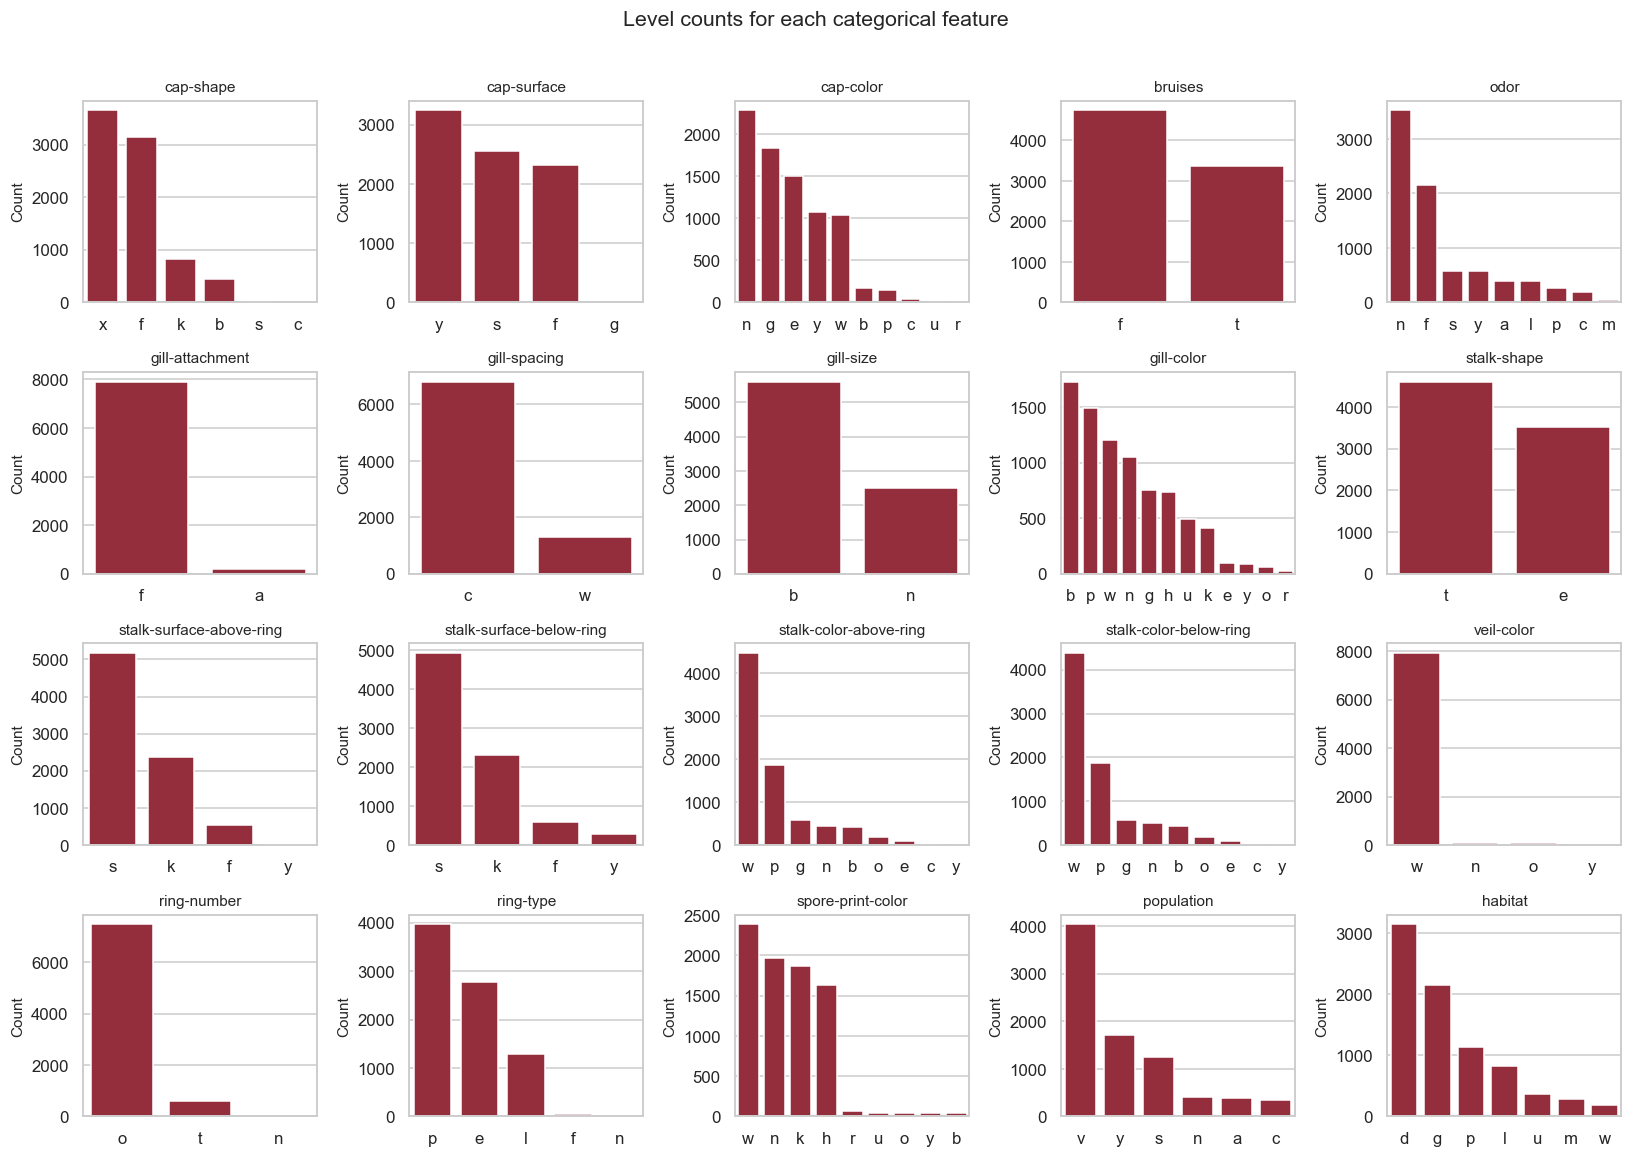

In [ ]:
# TODO: histogram grid of the numeric attributes.
features = [c for c in cleaned.columns if c != TARGET]
n_cols = 5
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.6 * n_rows))
for column, axis in zip(features, axes.flat):
    order = cleaned[column].value_counts().index
    sns.countplot(data=cleaned, x=column, order=order, ax=axis, color=PALETTE["primary"])
    axis.set_title(column, fontsize=10)
    axis.set_xlabel("")
    axis.set_ylabel("Count")
for axis in axes.flat[len(features):]:
    axis.set_visible(False)          # hide unused panels in the last row

plt.suptitle("Level counts for each categorical feature", y=1.01, fontsize=14)
plt.tight_layout()
save_fig("01_distributions")
plt.show()


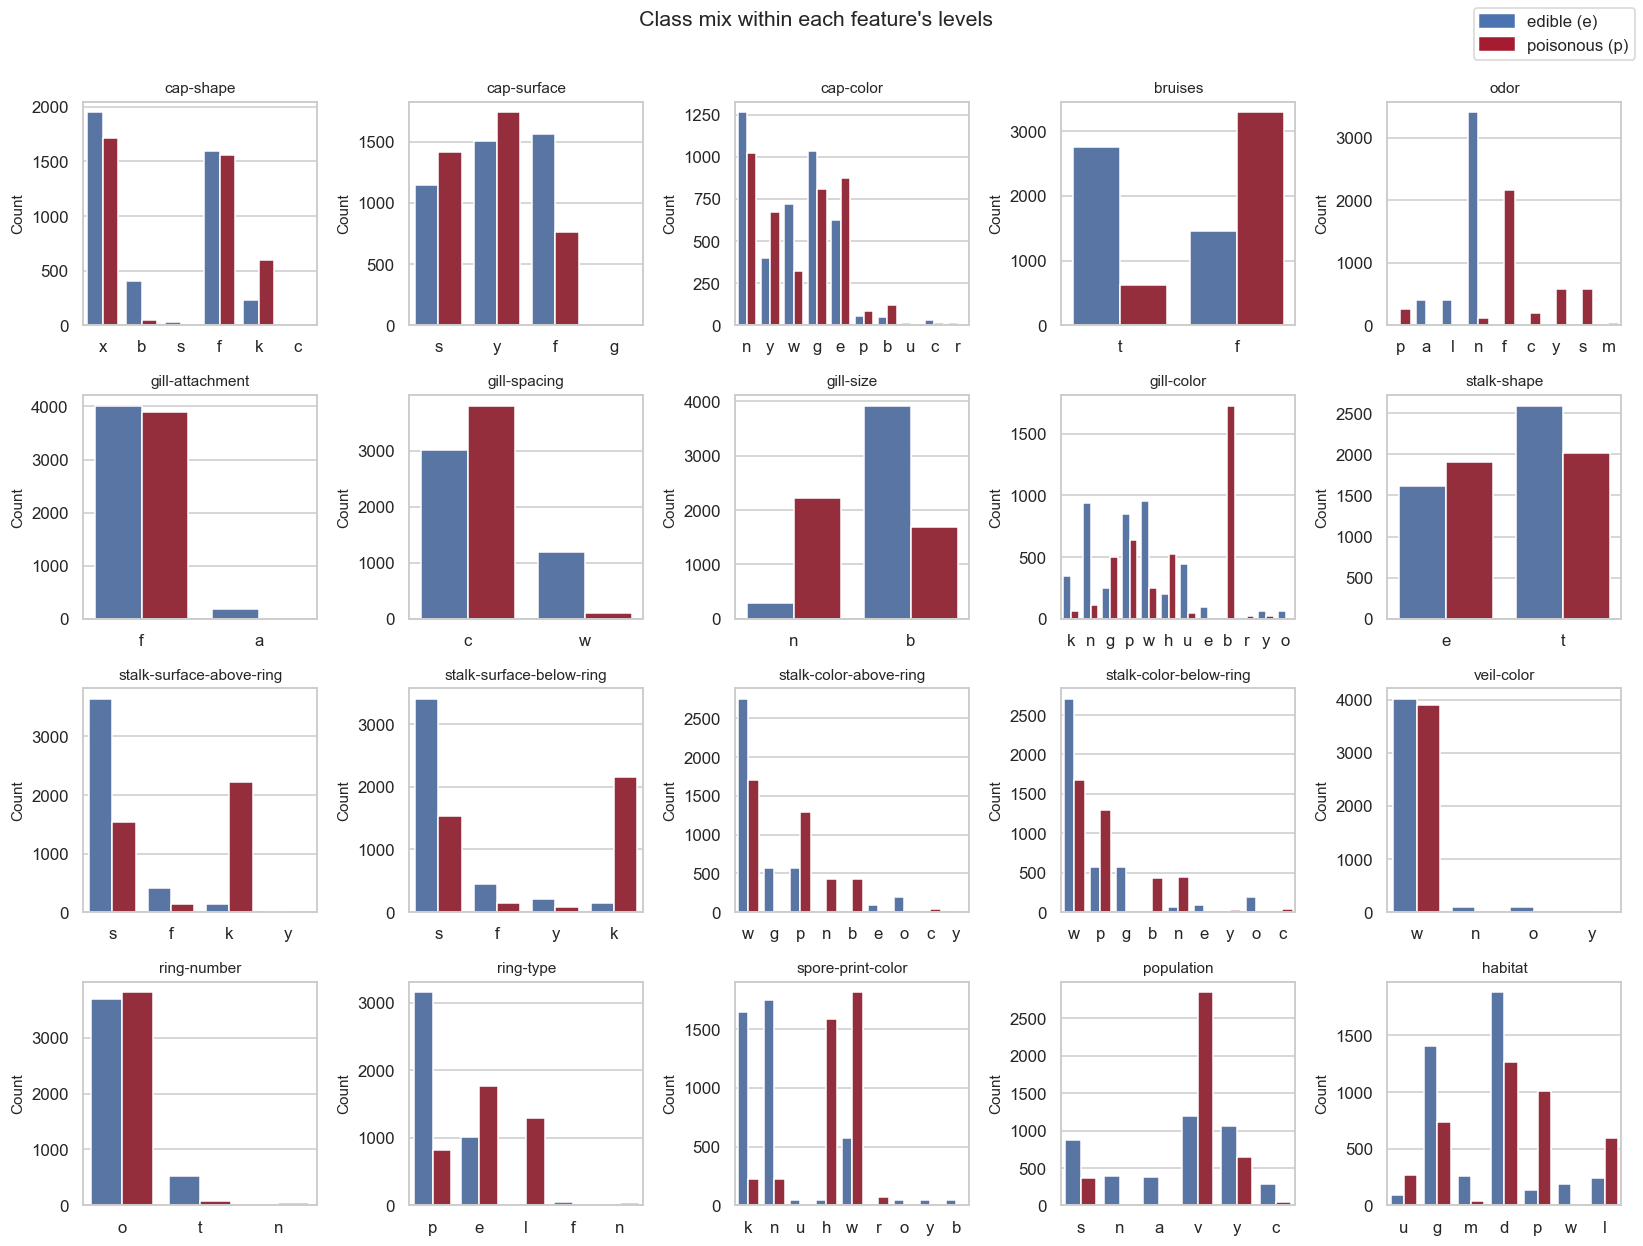

In [83]:
# TODO: target distribution, and the target against each categorical predictor.
# save_fig("02_target_and_categoricals")
features = [c for c in cleaned.columns if c != TARGET]
n_cols = 5
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.8 * n_rows))
for column, axis in zip(features, axes.flat):
    sns.countplot(data=cleaned, x=column, hue=TARGET, hue_order=["e", "p"], ax=axis,
                  palette=[PALETTE["secondary"], PALETTE["primary"]], legend=False)
    axis.set_title(column, fontsize=10)
    axis.set_xlabel("")
    axis.set_ylabel("Count")
for axis in axes.flat[len(features):]:
    axis.set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (PALETTE["secondary"], PALETTE["primary"])]
fig.legend(handles, ["edible (e)", "poisonous (p)"], loc="upper right")
plt.suptitle("Class mix within each feature's levels", y=1.01, fontsize=14)
plt.tight_layout()
save_fig("02_target_and_categoricals")
plt.show()

In [67]:
pd.crosstab(cleaned["odor"], cleaned[TARGET])
3408/(3408+120)

0.9659863945578231

Normality and skewness are not applicable here, since all features are categorical. The plots above show how the classes split across each feature's levels. `odor` stands out: 97% of odorless mushrooms are edible, almond and anise are essentially all edible, and levels such as foul and fishy are nearly all poisonous. Other relationships are less obvious, but `habitat`, `population`, `gill-color`, and `spore-print-color` show levels dominated by one class, so we treat them as candidate predictors to test in the feature-selection step. We should also note that there is no need for normalization and standardization due to the categorical nature of the features.

## 4. Encode, split, and examine training-set correlations

**Requirement:** convert categorical attributes to numerical ones if needed; analyze correlations among attributes
and with the target, numerically and visually.

> **Hint:** Split *before* any exploration that informs modeling, then compute every correlation from the training
> partition only. Choose the encoding deliberately: one-hot indicators, ordinal codes only if the order is real.
> If classification, think about stratifying the split.

In [75]:
y = cleaned[TARGET].map({"e": 0, "p": 1})        # 1 = poisonous
assert y.notna().all()                            # catches any unexpected class label

X = pd.get_dummies(cleaned.drop(columns=TARGET), dtype=float)   # drop_first defaults to False
print(X.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("\nTraining size:", X_train.shape[0])
print("\nTesting size:", X_test.shape[0])
print("\nTarget distribution in training:", y_train.value_counts(normalize=True))
print("\nTarget distribution in testing:", y_test.value_counts(normalize=True))

(8124, 111)

Training size: 6499

Testing size: 1625

Target distribution in training: poisonous
0   0.5179
1   0.4821
Name: proportion, dtype: float64

Target distribution in testing: poisonous
0   0.5182
1   0.4818
Name: proportion, dtype: float64


We want to investigate how each feature of `X_train` correlates to `y_train`. However, after one hot encoding each feature of the dataset, the heatmap required to visualize the correlationo matrix would be unreadable.

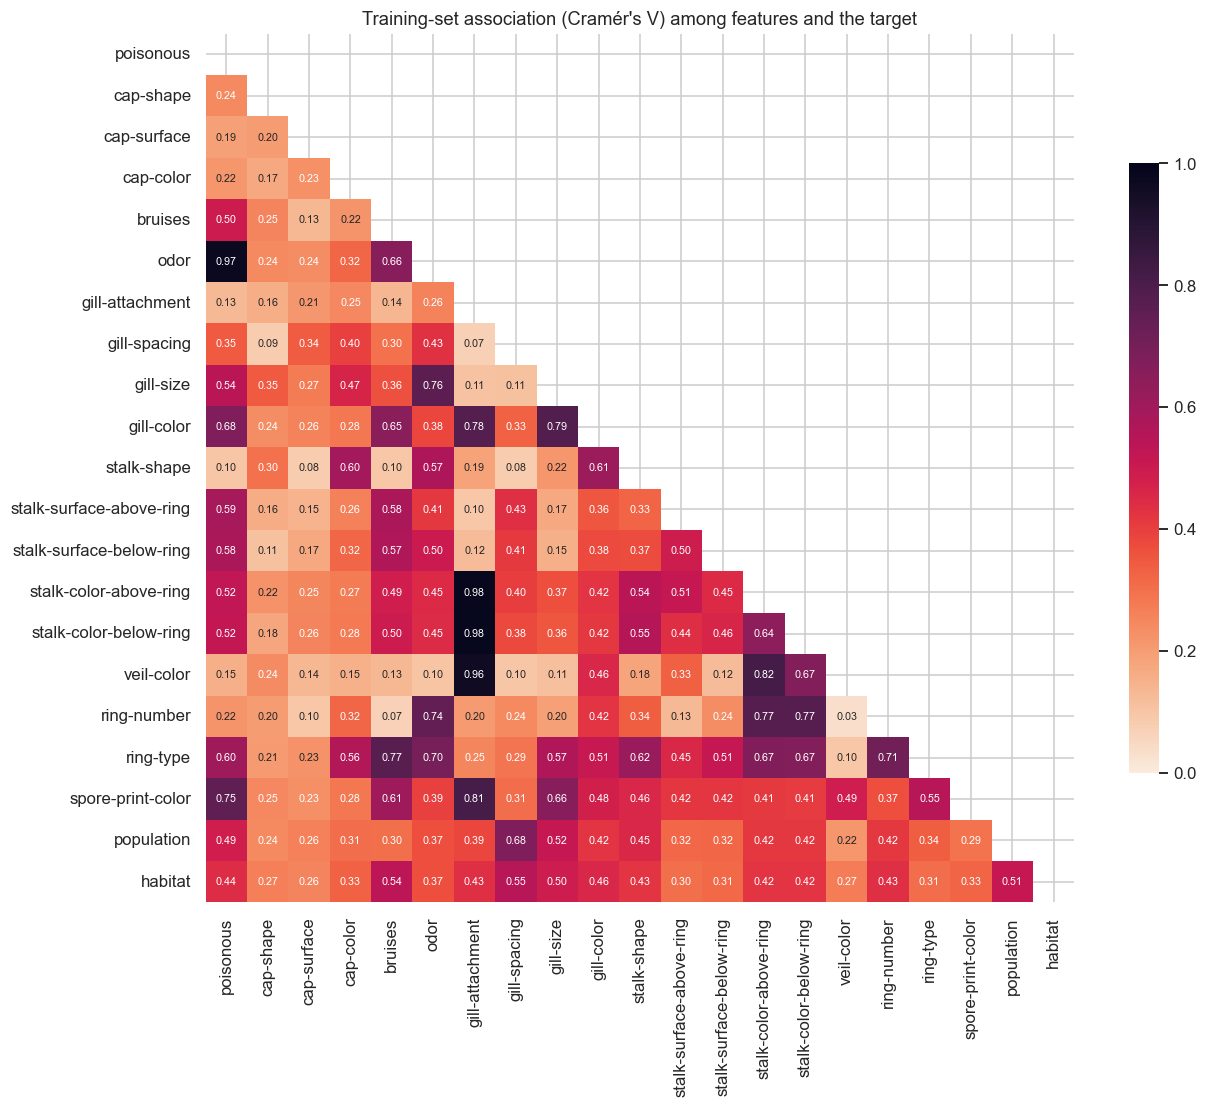

In [82]:
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    table = pd.crosstab(a, b)
    if min(table.shape) < 2:
        return 0.0
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.values.sum()
    return np.sqrt((chi2 / n) / (min(table.shape) - 1))

train_cat = cleaned.loc[X_train.index]          # unencoded, training rows only
cols = train_cat.columns.tolist()               # includes the target

V = pd.DataFrame(index=cols, columns=cols, dtype=float)
for a in cols:
    for b in cols:
        V.loc[a, b] = 1.0 if a == b else cramers_v(train_cat[a], train_cat[b])

mask = np.triu(np.ones_like(V, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(V, mask=mask, cmap="rocket_r", vmin=0, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True, cbar_kws={"shrink": 0.7})
plt.title("Training-set association (Cramér's V) among features and the target")
plt.tight_layout()
save_fig("03_cramers_v_heatmap")
plt.show()

In [ ]:
# TODO: bar chart of each predictor's correlation with the target (training set only).
# save_fig("04_target_correlations")

TODO: report the strongest predictor-target relationships and the most correlated predictor pairs, with numbers.

## 5. Standardize and normalize using training data only

**Requirement:** standardize and normalize the attributes.

> **Hint:** Fit each scaler on the training partition and only *apply* it to the test partition. Show both
> standardization and min-max normalization. Then think about this: do any of the four tree models change their
> predictions when feature scales change? Say so explicitly in the report, whichever way you conclude.

In [ ]:
# TODO: assert the train and test indices are disjoint and that sizes add up.

In [ ]:
# TODO: fit StandardScaler and MinMaxScaler on the training set, transform both partitions,
#       and show a small check table (training means/SDs, training and test min/max).

## 6. Identify the important attributes

**Requirement:** identify a few important attributes and proceed; do not use all attributes blindly.

> **Hint:** Any ranking or selection must use training data only. If you cross-validate the selection, recompute the
> ranking inside each fold. Consider comparing a correlation ranking against a model-based ranking (for example,
> impurity or permutation importance from a quick tree ensemble), and justify how many attributes you keep.

In [ ]:
# TODO: ranking method + cross-validated comparison of candidate subset sizes (training data only).
# TODO: export the evidence table to results/feature_selection_log.csv

In [ ]:
# TODO: plot the selection evidence.
# save_fig("05_feature_selection")

In [ ]:
# TODO: define selected_features, then X_train_selected and X_test_selected.

TODO: state which attributes were kept and why, including what you checked for sensitivity.

## 7. Shared tuning setup

**Requirement:** use `GridSearchCV` or similar for hyper-parameter tuning and cross-validation. It is up to you how
many parameters to tune, but you must convince yourself and the grader that the best values were found.

> **Hint:** Use *one* cross-validation splitter for all four models so their scores are comparable. Pick the scoring
> metric deliberately (accuracy can mislead on imbalanced classes). If any preprocessing is learned, put it inside a
> `Pipeline` so it is refit within each fold.

In [ ]:
# TODO: define model_cv (e.g. StratifiedKFold with shuffle=True and random_state=RANDOM_STATE) and SCORING.

In [ ]:
def classification_metrics(y_true, y_pred, y_score=None):
    """Return a dict of test metrics for one model.

    TODO: include accuracy, precision, recall, F1 (state the averaging if multiclass), ROC AUC, and
    average precision (PR AUC). y_score holds predicted probabilities for the ROC / PR metrics.
    """
    raise NotImplementedError("TODO: implement classification_metrics")

## 8. Tune the decision tree

**Requirement:** build and tune the the decision tree with `GridSearchCV`, and visualize the best estimator.

> **Hint:** Typical knobs: `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `ccp_alpha`. A single tree is high-variance, so watch the train-vs-CV gap. If the best value sits on the edge of your grid, widen the grid.

In [ ]:
# TODO: estimator (or Pipeline) and parameter grid for the the decision tree.
# TODO: print the total number of grid combinations.

In [ ]:
# TODO: GridSearchCV(estimator, param_grid, scoring=SCORING, cv=model_cv, n_jobs=-1, return_train_score=True)
#       and fit it on the TRAINING data only.

In [ ]:
# TODO: build the experiment log from cv_results_ (rank, mean/std CV score, mean train score, every parameter).
# TODO: export it to results/dt_experiment_log.csv and show the top rows.

In [ ]:
# TODO: plot the tuning results so you can see whether the best value is interior to the grid or on its edge.
# save_fig("06_dt_tuning")

In [ ]:
# TODO: best_dt = search.best_estimator_ ; print best params, best CV score, and the train-vs-CV gap.
# Do NOT score the test set here. Test evaluation happens once, in Section 12.

In [ ]:
# TODO: tree visualization. `sklearn.tree.plot_tree` needs no system install; `graphviz` is prettier but needs the Graphviz binary. Limit `max_depth` in the plot so it stays readable.
# save_fig("07_dt_tree")

TODO: interpret the the decision tree: which settings won, how sensitive the score is to them, and what the tree structure
and importances say about the problem.

## 9. Tune the random forest

**Requirement:** build and tune the the random forest with `GridSearchCV`, and visualize the best estimator.

> **Hint:** Typical knobs: `n_estimators`, `max_depth`, `max_features`, `min_samples_leaf`. Bigger forests rarely hurt accuracy but cost time, so decide where returns diminish. A forest has many trees: draw one from `best.estimators_` and also show feature importances.

In [ ]:
# TODO: estimator (or Pipeline) and parameter grid for the the random forest.
# TODO: print the total number of grid combinations.

In [ ]:
# TODO: GridSearchCV(estimator, param_grid, scoring=SCORING, cv=model_cv, n_jobs=-1, return_train_score=True)
#       and fit it on the TRAINING data only.

In [ ]:
# TODO: build the experiment log from cv_results_ (rank, mean/std CV score, mean train score, every parameter).
# TODO: export it to results/rf_experiment_log.csv and show the top rows.

In [ ]:
# TODO: plot the tuning results so you can see whether the best value is interior to the grid or on its edge.
# save_fig("08_rf_tuning")

In [ ]:
# TODO: best_rf = search.best_estimator_ ; print best params, best CV score, and the train-vs-CV gap.
# Do NOT score the test set here. Test evaluation happens once, in Section 12.

In [ ]:
# TODO: tree visualization. Plot one tree from the forest plus a feature-importance bar chart (consider permutation importance too).
# save_fig("09_rf_tree_and_importance")

TODO: interpret the the random forest: which settings won, how sensitive the score is to them, and what the tree structure
and importances say about the problem.

## 10. Tune AdaBoost

**Requirement:** build and tune the adaboost with `GridSearchCV`, and visualize the best estimator.

> **Hint:** AdaBoost boosts *weak* learners, so the depth of the base tree matters a lot. Typical knobs: base-tree `max_depth`, `n_estimators`, `learning_rate` (they trade off against each other). The base-learner argument is named `estimator` in recent scikit-learn and `base_estimator` in old versions; check yours.

In [ ]:
# TODO: estimator (or Pipeline) and parameter grid for the adaboost.
# TODO: print the total number of grid combinations.

In [ ]:
# TODO: GridSearchCV(estimator, param_grid, scoring=SCORING, cv=model_cv, n_jobs=-1, return_train_score=True)
#       and fit it on the TRAINING data only.

In [ ]:
# TODO: build the experiment log from cv_results_ (rank, mean/std CV score, mean train score, every parameter).
# TODO: export it to results/ada_experiment_log.csv and show the top rows.

In [ ]:
# TODO: plot the tuning results so you can see whether the best value is interior to the grid or on its edge.
# save_fig("10_ada_tuning")

In [ ]:
# TODO: best_ada = search.best_estimator_ ; print best params, best CV score, and the train-vs-CV gap.
# Do NOT score the test set here. Test evaluation happens once, in Section 12.

In [ ]:
# TODO: tree visualization. Plot one boosted tree (a stump is fine) plus the ensemble's feature importances.
# save_fig("11_ada_stump_and_importance")

TODO: interpret the adaboost: which settings won, how sensitive the score is to them, and what the tree structure
and importances say about the problem.

## 11. Tune XGBoost

**Requirement:** build and tune the xgboost with `GridSearchCV`, and visualize the best estimator.

> **Hint:** Typical knobs: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_lambda`, `gamma`. `XGBClassifier` expects class labels encoded as 0..K-1. This grid grows fast, so consider a staged search, but report what you did.

In [ ]:
# TODO: estimator (or Pipeline) and parameter grid for the xgboost.
# TODO: print the total number of grid combinations.

In [ ]:
# TODO: GridSearchCV(estimator, param_grid, scoring=SCORING, cv=model_cv, n_jobs=-1, return_train_score=True)
#       and fit it on the TRAINING data only.

In [ ]:
# TODO: build the experiment log from cv_results_ (rank, mean/std CV score, mean train score, every parameter).
# TODO: export it to results/xgb_experiment_log.csv and show the top rows.

In [ ]:
# TODO: plot the tuning results so you can see whether the best value is interior to the grid or on its edge.
# save_fig("12_xgb_tuning")

In [ ]:
# TODO: best_xgb = search.best_estimator_ ; print best params, best CV score, and the train-vs-CV gap.
# Do NOT score the test set here. Test evaluation happens once, in Section 12.

In [ ]:
# TODO: tree visualization. `xgboost.plot_tree` / `to_graphviz` need the Graphviz binary; `Booster.trees_to_dataframe()` and `xgboost.plot_importance` work without it.
# save_fig("13_xgb_tree_and_importance")

TODO: interpret the xgboost: which settings won, how sensitive the score is to them, and what the tree structure
and importances say about the problem.

## 12. Evaluate all four tuned models once on the same test set

**Requirement:** output and analyze the confusion matrix, precision, recall, and F-statistic, and include at least the
ROC and precision-recall plots.

> **Hint:** Touch the test set only now, after all tuning is finished. Also score a trivial baseline (for example
> always predicting the majority class) so the models' gains have a reference point. For a multiclass target, ROC and
> PR curves need a one-vs-rest treatment (`label_binarize`) and a stated averaging rule.

In [ ]:
# TODO: collect each tuned model's test predictions and predicted probabilities in dicts keyed by model name.

In [ ]:
# TODO: metrics table (baseline + four models) via classification_metrics, exported to results/model_comparison.csv.

In [ ]:
# TODO: confusion matrices for the four models in one figure, plus per-class precision/recall/F1 reports.
# save_fig("14_confusion_matrices")

In [ ]:
# TODO: ROC curves for the four models on one axes.
# save_fig("15_roc_curves")

In [ ]:
# TODO: precision-recall curves for the four models on one axes.
# save_fig("16_pr_curves")

In [ ]:
# TODO: side-by-side bar chart of the headline test metrics.
# save_fig("17_model_comparison")

TODO: interpret each plot. What do the confusion matrices show that accuracy hides? Where do the ROC and PR curves
disagree, and why?

## 13. Compare the models, conclusions, assumptions, and limitations

**Requirement:** compare the four models and state which works best and your analysis of the reason.

Answer each prompt in your own words (these become the report's discussion section):

1. **Predictive value relative to a baseline:** how much better than the trivial baseline is the best model?
2. **Best model and why:** which method wins on the test set, by how much, and is the margin larger than the
   cross-validation uncertainty? Explain the mechanism (bias-variance, bagging vs boosting, depth, regularization).
3. **Did tuning help?** Compare tuned models with sensible defaults if you have them.
4. **Single tree vs ensembles:** what do the ensembles buy, and what do they cost in interpretability?
5. **Where the models fail:** which classes or regions are hardest, and what does the confusion matrix say?
6. **Assumptions and limitations:** data collection, representativeness, leakage risks, anything omitted.

## Reproducibility checklist

- [ ] Public URL used; no local path is hard-coded.
- [ ] Raw dimensions asserted.
- [ ] Missingness, duplicates, categories, and consistency checked.
- [ ] The split is created before correlation analysis or learned preprocessing.
- [ ] Standardization and min-max normalization are fitted on training data and then applied to test data.
- [ ] Feature selection uses training data only.
- [ ] All four models tuned with `GridSearchCV` (or similar) using the same cross-validation splitter.
- [ ] Every experiment log exported to `results/`.
- [ ] Tree visualizations produced for all four models.
- [ ] Confusion matrix, precision, recall, F1, ROC, and precision-recall outputs produced for all four models.
- [ ] One fixed random seed used for the split, folds, and models.
- [ ] Final models evaluated once on the same untouched test partition.
- [ ] "Restart & Run All" completes from a clean kernel.